# SDXL LoRA Training with Kohya-ss
**Lab 3 — Generative AI Course 2026**

A personal LoRA adapter for SDXL.

## Step 1: Configuration

In [1]:

import os
print("Available datasets:")
for d in os.listdir('/kaggle/input/'):
    print(f"  /kaggle/input/{d}/")
  
  
    subpath = f'/kaggle/input/{d}'
    for f in sorted(os.listdir(subpath))[:5]:
        print(f"    {f}")
    if len(os.listdir(subpath)) > 5:
        print(f"    ... and {len(os.listdir(subpath))-5} more files")

Available datasets:
  /kaggle/input/datasets/
    mirchukliliana


In [2]:
DATASET_DIR = "/kaggle/input/datasets/mirchukliliana/lora-dataset-liliana"

OUTPUT_DIR = "/kaggle/working/lora_output"
OUTPUT_NAME = "my_lora_v1"

TRIGGER_WORD = "ohwx woman"

RESOLUTION = 1024
TRAIN_BATCH_SIZE = 1
MAX_TRAIN_STEPS = 1500
LEARNING_RATE = 1e-4
NETWORK_DIM = 16
NETWORK_ALPHA = 8
SAVE_EVERY_N_STEPS = 500

## Step 2: Setup Environment

In [3]:
import psutil, subprocess
ram = psutil.virtual_memory()
print(f"System RAM: {ram.total/1e9:.1f} GB total, {ram.available/1e9:.1f} GB free")
result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total,memory.free', '--format=csv,noheader'], capture_output=True, text=True)
print(f"GPU: {result.stdout.strip()}")

System RAM: 33.7 GB total, 32.4 GB free
GPU: Tesla T4, 15360 MiB, 14913 MiB
Tesla T4, 15360 MiB, 14913 MiB


In [4]:
!git clone https://github.com/kohya-ss/sd-scripts.git /kaggle/working/sd-scripts
%cd /kaggle/working/sd-scripts
!pip install -q -r requirements.txt
!pip install -q xformers

fatal: destination path '/kaggle/working/sd-scripts' already exists and is not an empty directory.
/kaggle/working/sd-scripts
  Preparing metadata (setup.py) ... done


In [5]:
import os
os.makedirs(os.path.expanduser('~/.cache/huggingface/accelerate'), exist_ok=True)

accelerate_config = """compute_environment: LOCAL_MACHINE
debug: false
distributed_type: 'NO'
downcast_bf16: 'no'
gpu_ids: '0'
machine_rank: 0
main_training_function: main
mixed_precision: fp16
num_machines: 1
num_processes: 1
rdzv_backend: static
same_network: true
tpu_env: []
tpu_use_cluster: false
tpu_use_sudo: false
use_cpu: false
"""

config_path = os.path.expanduser('~/.cache/huggingface/accelerate/default_config.yaml')
with open(config_path, 'w') as f:
    f.write(accelerate_config)
print("Accelerate config written.")

Accelerate config written.


## Step 3: Prepare Dataset Structure
Kohya-ss expects a specific folder structure:
```
train_data/
  <num_repeats>_<class>/
    image1.jpg
    image1.txt
    ...
```

In [6]:
import shutil
from pathlib import Path

src = Path(DATASET_DIR)
images = list(src.glob('*.jpg')) + list(src.glob('*.jpeg')) + list(src.glob('*.png'))
num_images = len(images)
print(f"Found {num_images} images in {DATASET_DIR}")

if num_images == 0:
    # Maybe images are in a subfolder
    images = list(src.rglob('*.jpg')) + list(src.rglob('*.jpeg')) + list(src.rglob('*.png'))
    num_images = len(images)
    print(f"Found {num_images} images recursively")

assert num_images > 0, f"No images found in {DATASET_DIR}! Check the path."

repeats = max(1, round(200 / num_images))
print(f"Using {repeats} repeats per image ({repeats * num_images} images per epoch)")

train_dir = Path('/kaggle/working/train_data')
subset_dir = train_dir / f'{repeats}_ohwx'
if train_dir.exists():
    shutil.rmtree(train_dir)
subset_dir.mkdir(parents=True, exist_ok=True)

copied = 0
for img in images:
    shutil.copy2(img, subset_dir / img.name)
    txt = img.with_suffix('.txt')
    if txt.exists():
        shutil.copy2(txt, subset_dir / txt.name)
    copied += 1

print(f"Copied {copied} images to {subset_dir}")

Found 35 images in /kaggle/input/datasets/mirchukliliana/lora-dataset-liliana
Using 6 repeats per image (210 images per epoch)
Copied 35 images to /kaggle/working/train_data/6_ohwx


In [7]:
from pathlib import Path

subset = Path('/kaggle/working/train_data')
all_imgs = list(subset.rglob('*.jpg')) + list(subset.rglob('*.jpeg')) + list(subset.rglob('*.png'))
all_txts = list(subset.rglob('*.txt'))

print(f"Images: {len(all_imgs)}")
print(f"Captions: {len(all_txts)}")

missing = [img.name for img in all_imgs if not img.with_suffix('.txt').exists()]
if missing:
    print(f"\nWARNING: {len(missing)} images missing captions: {missing[:5]}")

print("\nSample captions:")
for txt in sorted(all_txts)[:3]:
    print(f"  {txt.name}: {txt.read_text()[:120]}...")

Images: 35
Captions: 35

Sample captions:
  01.txt: a photo of ohwx woman with long straight light brown hair, fair skin, green eyes, gentle smile, standing in front of an ...
  02.txt: a photo of ohwx woman with long straight light brown hair, fair skin, green eyes, soft smile, standing in front of a cla...
  03.txt: a photo of ohwx woman with long straight light brown hair, fair skin, green eyes, smiling on a staircase indoors, wearin...


## Step 4: Train LoRA

**Kaggle T4 setup — clean mixed precision, no hacks needed:**
- `mixed_precision=fp16` — fp16 for forward/backward, fp32 master weights
- **NO `--full_fp16`** — this caused grey/washed-out images on Colab
- **NO manual latent pre-caching** — kohya handles caching natively (30GB RAM can load full model)
- Adafactor optimizer (low VRAM)
- Gradient checkpointing
- UNet-only training

**Training ~1500 steps takes approximately 45-75 minutes on T4.**

In [8]:
sample_prompts = f"""a photo of {TRIGGER_WORD} with long straight light brown hair, fair skin, green eyes, gentle smile, wearing a cream cardigan, standing in front of a building, bright daylight --n low quality, blurry, deformed --w 1024 --h 1024 --l 7 --s 28
a photo of {TRIGGER_WORD} with long straight light brown hair, fair skin, green eyes, bright smile, standing by a railing, wearing a brown satin shirt, library background --n low quality, blurry, deformed --w 1024 --h 1024 --l 7 --s 28
a close-up photo of {TRIGGER_WORD} with long straight light brown hair, fair skin with freckles, green eyes, warm smile, wearing a white eyelet lace blouse, outdoors --n low quality, blurry, deformed --w 1024 --h 1024 --l 7 --s 28
"""

with open('/kaggle/working/sample_prompts.txt', 'w') as f:
    f.write(sample_prompts)

print("Sample prompts written.")
print(sample_prompts)

Sample prompts written.
a photo of ohwx woman with long straight light brown hair, fair skin, green eyes, gentle smile, wearing a cream cardigan, standing in front of a building, bright daylight --n low quality, blurry, deformed --w 1024 --h 1024 --l 7 --s 28
a photo of ohwx woman with long straight light brown hair, fair skin, green eyes, bright smile, standing by a railing, wearing a brown satin shirt, library background --n low quality, blurry, deformed --w 1024 --h 1024 --l 7 --s 28
a close-up photo of ohwx woman with long straight light brown hair, fair skin with freckles, green eyes, warm smile, wearing a white eyelet lace blouse, outdoors --n low quality, blurry, deformed --w 1024 --h 1024 --l 7 --s 28



In [9]:
from huggingface_hub import snapshot_download
snapshot_download("stabilityai/stable-diffusion-xl-base-1.0", 
                  allow_patterns=["*.fp16.safetensors", "*.json", "*.txt"],
                  resume_download=True)
print("Download complete!")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Fetching 22 files:   0%|          | 0/22 [00:00<?, ?it/s]

Download complete!


In [10]:
import os, gc, torch
os.makedirs(OUTPUT_DIR, exist_ok=True)

gc.collect()
torch.cuda.empty_cache()

SDXL_MODEL = "stabilityai/stable-diffusion-xl-base-1.0"

# Kaggle has 30GB RAM — no need for --lowram or --full_fp16 hacks!
# Standard mixed precision training with fp32 master weights = best quality.
!SAFETENSORS_FAST_GPU=1 PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True \
    accelerate launch \
    --num_processes=1 \
    --num_machines=1 \
    --mixed_precision=fp16 \
    /kaggle/working/sd-scripts/sdxl_train_network.py \
    --pretrained_model_name_or_path="{SDXL_MODEL}" \
    --train_data_dir="/kaggle/working/train_data" \
    --output_dir="{OUTPUT_DIR}" \
    --output_name="{OUTPUT_NAME}" \
    --save_model_as=safetensors \
    --resolution={RESOLUTION} \
    --train_batch_size={TRAIN_BATCH_SIZE} \
    --max_train_steps={MAX_TRAIN_STEPS} \
    --learning_rate={LEARNING_RATE} \
    --network_module=networks.lora \
    --network_dim={NETWORK_DIM} \
    --network_alpha={NETWORK_ALPHA} \
    --network_train_unet_only \
    --optimizer_type="Adafactor" \
    --optimizer_args "scale_parameter=False" "relative_step=False" "warmup_init=False" \
    --lr_scheduler="constant_with_warmup" \
    --lr_warmup_steps=100 \
    --mixed_precision=fp16 \
    --save_precision=fp16 \
    --gradient_checkpointing \
    --cache_text_encoder_outputs \
    --cache_text_encoder_outputs_to_disk \
    --cache_latents \
    --cache_latents_to_disk \
    --no_half_vae \
    --xformers \
    --save_every_n_steps={SAVE_EVERY_N_STEPS} \
    --max_data_loader_n_workers=2 \
    --caption_extension=".txt" \
    --seed=42 \
    2>&1 | tee /kaggle/working/train.log

2026-04-13 18:03:22.997667: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776103403.021134    1332 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776103403.028528    1332 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776103403.048186    1332 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776103403.048213    1332 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776103403.048216    1332 computation_placer.cc:177] computation placer alr

In [11]:
# Verify training completed
!ls -la {OUTPUT_DIR}/

import psutil, subprocess
ram = psutil.virtual_memory()
print(f"\nSystem RAM: {ram.total/1e9:.1f} GB total, {ram.available/1e9:.1f} GB free")
result = subprocess.run(['nvidia-smi', '--query-gpu=memory.total,memory.free', '--format=csv,noheader,nounits'], capture_output=True, text=True)
print(f"GPU VRAM: {result.stdout.strip()} MiB (total, free)")

total 333720
drwxr-xr-x 2 root root     4096 Apr 13 19:12 .
drwxr-xr-x 6 root root     4096 Apr 13 18:03 ..
-rw-r--r-- 1 root root 85426652 Apr 13 19:12 my_lora_v1.safetensors
-rw-r--r-- 1 root root 85426652 Apr 13 18:27 my_lora_v1-step00000500.safetensors
-rw-r--r-- 1 root root 85426652 Apr 13 18:50 my_lora_v1-step00001000.safetensors
-rw-r--r-- 1 root root 85426652 Apr 13 19:12 my_lora_v1-step00001500.safetensors

System RAM: 33.7 GB total, 32.1 GB free
GPU VRAM: 15360, 14913
15360, 14913 MiB (total, free)


## Step 5: Generate Images with Your LoRA
After training completes, generate test images to evaluate your LoRA.

In [12]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

from diffusers import StableDiffusionXLPipeline, EulerAncestralDiscreteScheduler
from pathlib import Path

lora_files = sorted(Path(OUTPUT_DIR).glob(f"{OUTPUT_NAME}*.safetensors"))
if not lora_files:
    raise FileNotFoundError("No LoRA files found! Make sure training completed.")

print(f"Found LoRA files: {[f.name for f in lora_files]}")
LORA_PATH = str(lora_files[-1])
print(f"Using: {LORA_PATH}")

pipe = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True,
)
pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)
pipe.to("cuda")

pipe.load_lora_weights(LORA_PATH)
print("\nPipeline ready with LoRA loaded!")

2026-04-13 19:13:06.734752: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776107586.758945    1275 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776107586.766824    1275 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776107586.790729    1275 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776107586.790870    1275 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776107586.790877    1275 computation_placer.cc:177] computation placer alr

Found LoRA files: ['my_lora_v1-step00000500.safetensors', 'my_lora_v1-step00001000.safetensors', 'my_lora_v1-step00001500.safetensors', 'my_lora_v1.safetensors']
Using: /kaggle/working/lora_output/my_lora_v1.safetensors


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]


Pipeline ready with LoRA loaded!


Generating [1/5]: a close-up selfie of ohwx woman with long straight light brown hair, fair skin, ...


  0%|          | 0/28 [00:00<?, ?it/s]

Generating [2/5]: a photo of ohwx woman with long straight light brown hair, fair skin, green eyes...


  0%|          | 0/28 [00:00<?, ?it/s]

Generating [3/5]: a photo of ohwx woman with long straight light brown hair, fair skin, green eyes...


  0%|          | 0/28 [00:00<?, ?it/s]

Generating [4/5]: a close-up selfie of ohwx woman with long straight light brown hair, fair skin, ...


  0%|          | 0/28 [00:00<?, ?it/s]

Generating [5/5]: a photo of ohwx woman with long straight light brown hair, fair skin with freckl...


  0%|          | 0/28 [00:00<?, ?it/s]

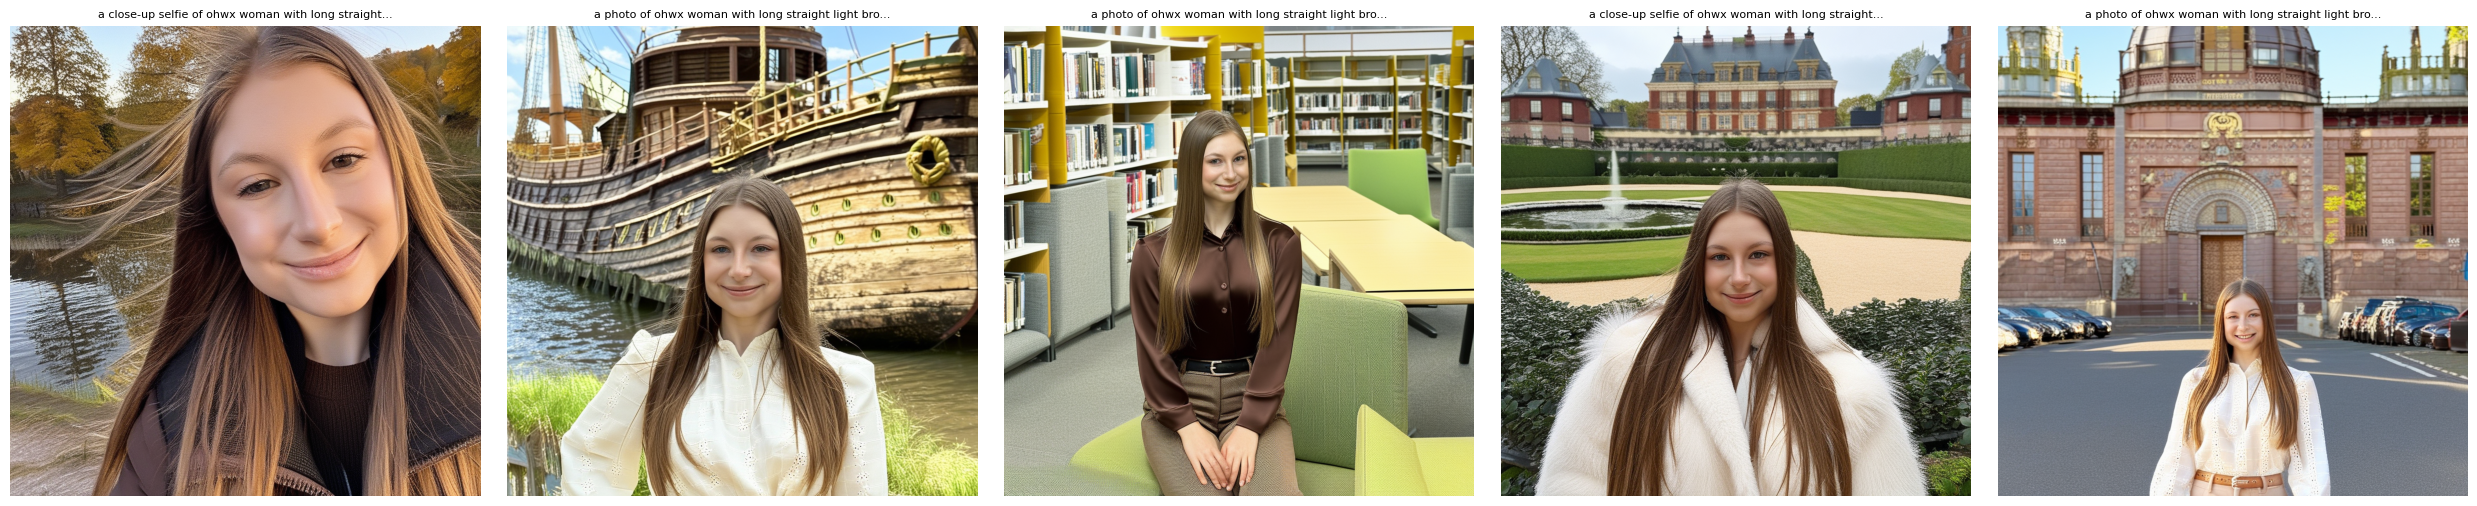


5 images generated and saved to /kaggle/working/lora_output


In [13]:
import matplotlib.pyplot as plt

test_prompts = [
    f"a close-up selfie of {TRIGGER_WORD} with long straight light brown hair, fair skin, green eyes, warm smile, wearing a black jacket and brown sweater, autumn lakeside",
    f"a photo of {TRIGGER_WORD} with long straight light brown hair, fair skin, green eyes, gentle smile, standing in front of an old wooden ship, wearing a white blouse",
    f"a photo of {TRIGGER_WORD} with long straight light brown hair, fair skin, green eyes, soft smile, sitting in a library, wearing a brown satin shirt, warm indoor lighting",
    f"a close-up selfie of {TRIGGER_WORD} with long straight light brown hair, fair skin, green eyes, warm smile, wearing a white fur coat, overlooking a formal garden",
    f"a photo of {TRIGGER_WORD} with long straight light brown hair, fair skin with freckles, green eyes, cheerful smile, standing in front of a building, wearing a white eyelet lace blouse, natural daylight",
]

negative_prompt = "low quality, blurry, deformed, disfigured, bad anatomy, extra limbs"

images = []
for i, prompt in enumerate(test_prompts):
    print(f"Generating [{i+1}/{len(test_prompts)}]: {prompt[:80]}...")
    image = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=28,
        guidance_scale=7.0,
        width=1024,
        height=1024,
        generator=torch.Generator("cuda").manual_seed(42),
    ).images[0]
    images.append(image)
    image.save(f"{OUTPUT_DIR}/generated_{i+1}.png")

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for ax, img, prompt in zip(axes, images, test_prompts):
    ax.imshow(img)
    ax.set_title(prompt[:50] + "...", fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/results_grid.png", dpi=150)
plt.show()

print(f"\n{len(images)} images generated and saved to {OUTPUT_DIR}")

## Step 6: Compare Checkpoints
Compare LoRA quality at different training steps to find the sweet spot.

Found 4 checkpoints: ['my_lora_v1-step00000500.safetensors', 'my_lora_v1-step00001000.safetensors', 'my_lora_v1-step00001500.safetensors', 'my_lora_v1.safetensors']

Loading my_lora_v1-step00000500.safetensors...


  0%|          | 0/28 [00:00<?, ?it/s]


Loading my_lora_v1-step00001000.safetensors...


  0%|          | 0/28 [00:00<?, ?it/s]


Loading my_lora_v1-step00001500.safetensors...


  0%|          | 0/28 [00:00<?, ?it/s]


Loading my_lora_v1.safetensors...


  0%|          | 0/28 [00:00<?, ?it/s]

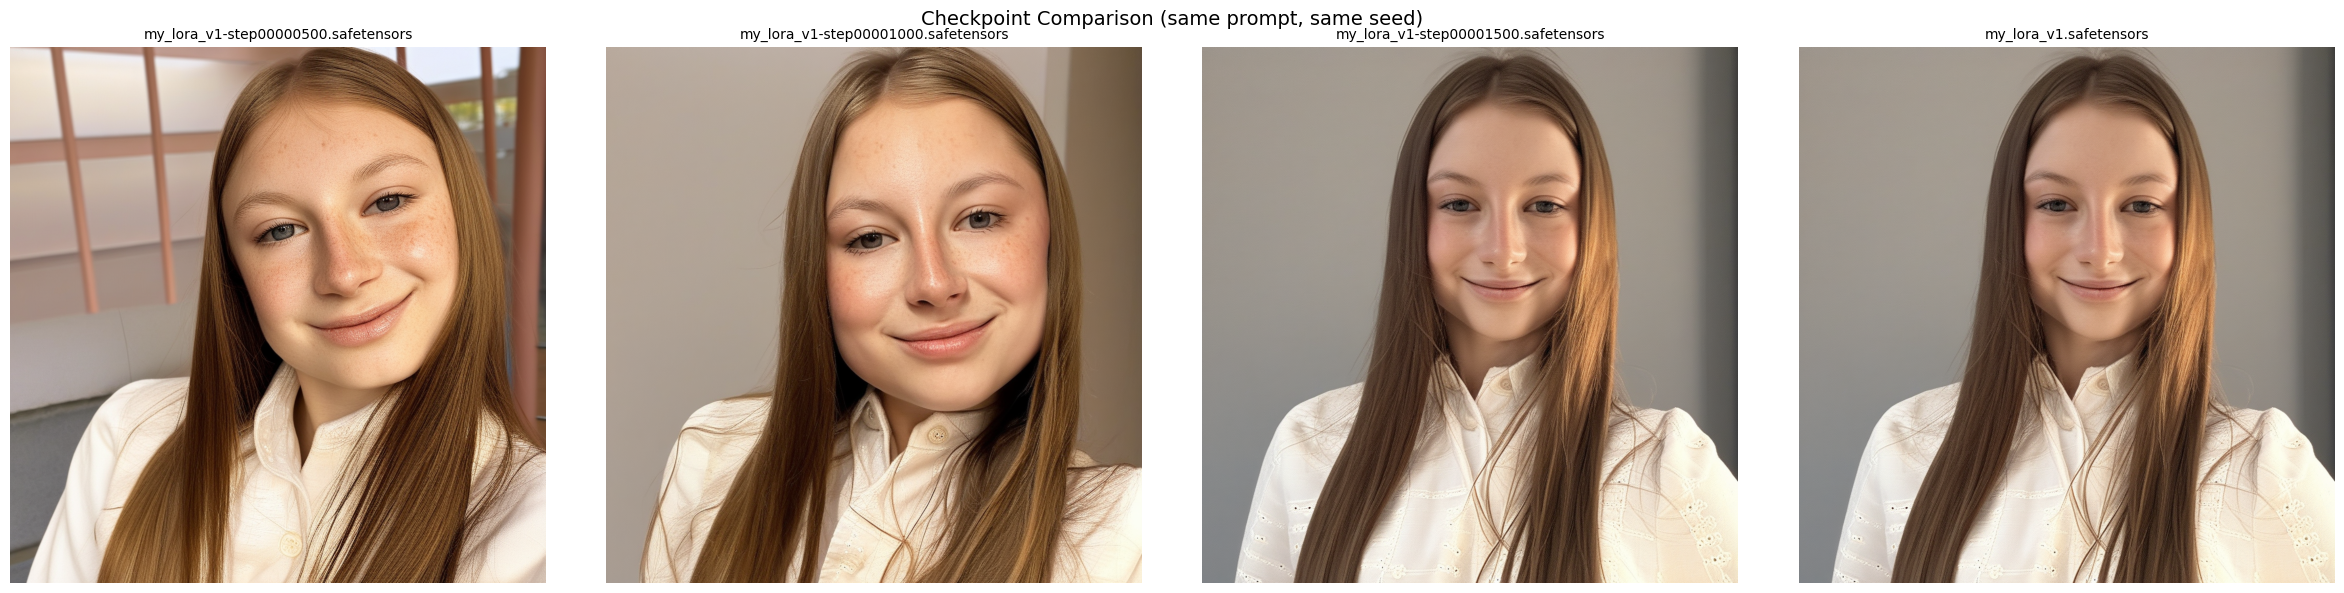

In [14]:
from pathlib import Path
import matplotlib.pyplot as plt

checkpoints = sorted(Path(OUTPUT_DIR).glob(f"{OUTPUT_NAME}*.safetensors"))
print(f"Found {len(checkpoints)} checkpoints: {[c.name for c in checkpoints]}")

test_prompt = f"a close-up photo of {TRIGGER_WORD} with long straight light brown hair, fair skin with freckles, green eyes, gentle warm smile, wearing a white blouse, natural daylight"
negative_prompt = "low quality, blurry, deformed"

comparison_images = []
for ckpt in checkpoints:
    print(f"\nLoading {ckpt.name}...")
    pipe.unload_lora_weights()
    pipe.load_lora_weights(str(ckpt))

    img = pipe(
        prompt=test_prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=28,
        guidance_scale=7.0,
        width=1024, height=1024,
        generator=torch.Generator("cuda").manual_seed(42),
    ).images[0]
    comparison_images.append((ckpt.name, img))

n = len(comparison_images)
fig, axes = plt.subplots(1, n, figsize=(6*n, 6))
if n == 1:
    axes = [axes]
for ax, (name, img) in zip(axes, comparison_images):
    ax.imshow(img)
    ax.set_title(name, fontsize=10)
    ax.axis('off')
plt.suptitle("Checkpoint Comparison (same prompt, same seed)", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/checkpoint_comparison.png", dpi=150)
plt.show()

## Step 7: Download Results
Download your trained LoRA weights and generated images.

In [15]:
import os
print("Output files:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    size_mb = os.path.getsize(f"{OUTPUT_DIR}/{f}") / 1e6
    print(f"  {f} ({size_mb:.1f} MB)")

print(f"\nTotal files: {len(os.listdir(OUTPUT_DIR))}")
print("These will be available in the Output tab after notebook execution.")

Output files:
  checkpoint_comparison.png (3.4 MB)
  generated_1.png (2.4 MB)
  generated_2.png (1.8 MB)
  generated_3.png (1.9 MB)
  generated_4.png (2.0 MB)
  generated_5.png (1.5 MB)
  my_lora_v1-step00000500.safetensors (85.4 MB)
  my_lora_v1-step00001000.safetensors (85.4 MB)
  my_lora_v1-step00001500.safetensors (85.4 MB)
  my_lora_v1.safetensors (85.4 MB)
  results_grid.png (5.1 MB)

Total files: 11
These will be available in the Output tab after notebook execution.
